In [1]:
from flax import linen as nn
import jax.numpy as jnp
import jax
import math

In [2]:
class PINN(nn.Module):
    features: list 
    # An example of above list is [64,64,1]
    def setup(self):
        self.layers = [nn.Dense(f) for f in self.features]
        # In the above we define the layers
        
    def __call__(self,x):
        # Define the forward pass
        for i, lyr in enumerate(self.layers):
            x = lyr(x)
            if i<len(self.layers)-1:
                x = nn.tanh(x)
                # This is the application of activation function
                # except at the last layer.
        return x
        

In [3]:
model = PINN(features = [64,64,1])

In [4]:
key = jax.random.PRNGKey(0)
dummy_input = jnp.ones((1,1))
params = model.init(key, dummy_input)['params']

In [5]:
# This is called a wrapper. It is the evaluation of model at some input
def u_pred(params, x):
    # To do this we first put x and t into the same array
    input_vec = jnp.array([x])
    # Now we see how the model actually combines the parameters
    # and the input to given an ouput
    # Basically run theforward pass
    return model.apply({'params': params}, input_vec)[0]
print(u_pred(params,1))

0.30590987


In [6]:
# u_pred1 = u_pred(params,1)
du_dx = jax.grad(u_pred, argnums = 1)
# The above means that the u_pred is being differentiated with respect ot x
# print(du_dx.apply({'params':params},1)[0])
print(du_dx(params,1.0))
d2u_dx2 = jax.grad(du_dx, argnums = 1)

# here we have created the second derivative
print(d2u_dx2)

0.06815469
<function u_pred at 0x7be4c82b8860>


**Now we define the PDE which we are trying to solve**

In [7]:
def residual(params, x):
    return d2u_dx2(params,x) + 2

In [8]:
# We have to vectorise the residual so that it can handle
# entire batch of data at once
v_pde_residual = jax.vmap(residual, in_axes=(None,0))

# Now comes the main definition of the pde_residual
def physics_loss(params, x_batch):
    loss = v_pde_residual(params, x_batch)
    return jnp.mean(jnp.square(loss))

In [9]:
import optax

# FIrst we define the optimizer which is the usual Adam
# This is done through the module optax

from flax.training import train_state
optimizer = optax.inject_hyperparams(optax.adam)(learning_rate=1e-3)

# We create the initial state of the model
state = train_state.TrainState.create(
    apply_fn=model.apply,
    params=params,
    tx=optimizer)

In [10]:
# We need to add some boundary values
x_boundary = 0.0
u_boundary = 1.0
du_dx_boundary = 1.0

# ALso we vectorise the du_dx 
v_du_dx = jax.vmap(du_dx, in_axes = (None,0))

In [11]:
# I still have to understand the use of the command below
@jax.jit
def train_step(state, x_batch, x_boundary, u_boundary, du_dx_boundary):
    def loss_fn(params):
        
        # This is the pde loss
        pde_loss = physics_loss(params, x_batch)

        # Then we add the Dirichlet boundary condition
        # u_boundary_pred = state.apply_fn({'params' : params}, jnp.stack([x_boundary], axis=-1))
        u_boundary_pred = u_pred(params, x_boundary)
        boundary_dr_loss= jnp.mean(jnp.square(u_boundary_pred-u_boundary))

        # now we add the neumann boundary condition at the same boundary point
        du_dx_pred = du_dx(params, x_boundary)
    
        loss_neumann = jnp.mean(jnp.square(du_dx_pred - du_dx_boundary))
        return 10*pde_loss + boundary_dr_loss + loss_neumann
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss

In [12]:
# These are the point where we want to evaluate the trained network on.
# These are usually higher than the collocation points which demonstrates
# the advanatage of PINNs.

x_batch = jnp.linspace(0,10,100)

In [13]:
loss_track=[]
epochs = 200000
# train_step_track=[]
for step in range(epochs):
    state, loss_val = train_step(state, x_batch, x_boundary, u_boundary, du_dx_boundary)
    if step % 100 == 0:
        order = -(math.ceil(abs(math.log10(loss_val)))+1)
        new_lr = 10^order
        new_lr = max(1e-6, min(new_lr, 1e-2))
        new_hyperparams = {**state.opt_state.hyperparams, 'learning_rate': new_lr}
        state = state.replace(
        opt_state=state.opt_state._replace(hyperparams=new_hyperparams)
    )
    loss_track.append([loss_val,step])
    if step % 1000 == 0:
        print(f"Step {step}, Loss: {loss_val:.4e}")

Step 0, Loss: 3.9335e+01
Step 1000, Loss: 3.7338e+01
Step 2000, Loss: 3.7062e+01
Step 3000, Loss: 3.6824e+01
Step 4000, Loss: 3.6604e+01
Step 5000, Loss: 3.6401e+01
Step 6000, Loss: 3.6213e+01
Step 7000, Loss: 3.6039e+01
Step 8000, Loss: 3.5877e+01
Step 9000, Loss: 3.5726e+01
Step 10000, Loss: 3.5584e+01
Step 11000, Loss: 3.5451e+01
Step 12000, Loss: 3.5325e+01
Step 13000, Loss: 3.5207e+01
Step 14000, Loss: 3.5097e+01
Step 15000, Loss: 3.4993e+01
Step 16000, Loss: 3.4896e+01
Step 17000, Loss: 3.4805e+01
Step 18000, Loss: 3.4719e+01
Step 19000, Loss: 3.4637e+01
Step 20000, Loss: 3.4561e+01
Step 21000, Loss: 3.4489e+01
Step 22000, Loss: 3.4420e+01
Step 23000, Loss: 3.4355e+01
Step 24000, Loss: 3.4293e+01
Step 25000, Loss: 3.4235e+01
Step 26000, Loss: 3.4180e+01
Step 27000, Loss: 3.4128e+01
Step 28000, Loss: 3.4078e+01
Step 29000, Loss: 3.4031e+01
Step 30000, Loss: 3.3985e+01
Step 31000, Loss: 3.3942e+01
Step 32000, Loss: 3.3901e+01
Step 33000, Loss: 3.3861e+01
Step 34000, Loss: 3.3823e+0

In [68]:
import numpy as np
x_check = np.linspace(0,10,1000)
v_u_pred = jax.vmap(u_pred, in_axes=(None,0))
y_check = v_u_pred(state.params,x_check)

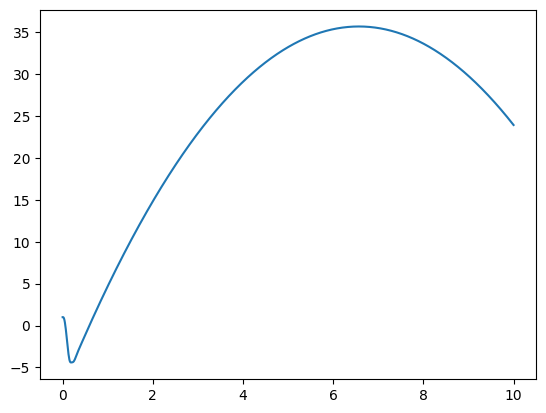

In [69]:
import matplotlib.pyplot as plt
plt.plot(x_check,y_check)